In [ ]:
import os
import rasterio
import numpy as np
from PIL import Image
import ee
import geemap
import random
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, ConcatDataset
from torchvision import transforms
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

In [12]:

def converter_dataset(pasta_origem, pasta_destino, eh_mascara=False):
    os.makedirs(pasta_destino, exist_ok=True)
    arquivos = [f for f in os.listdir(pasta_origem) if f.endswith('.tif')]
    
    print(f"Convertendo {len(arquivos)} arquivos de {pasta_origem}...")

    for arquivo in arquivos:
        caminho_in = os.path.join(pasta_origem, arquivo)
        caminho_out = os.path.join(pasta_destino, arquivo.replace('.tif', '.png'))
        
        with rasterio.open(caminho_in) as src:
            if eh_mascara:
                data = src.read(1)
                data = (data * 255).astype(np.uint8)
                img = Image.fromarray(data)
            else:
                data = src.read([1, 2, 3]).transpose(1, 2, 0)
                
                p2, p98 = np.percentile(data, (2, 98))
                data_norm = np.clip((data - p2) / (p98 - p2) * 255, 0, 255).astype(np.uint8)
                img = Image.fromarray(data_norm)
            
            img.save(caminho_out)

converter_dataset('dataset_tif/images', 'dataset/images', eh_mascara=False)

converter_dataset('dataset_tif/masks', 'dataset/masks', eh_mascara=True)


Convertendo 56 arquivos de dataset_tif/images...


C:\Users\danie\AppData\Local\Temp\ipykernel_14940\1018468645.py:20: RuntimeWarning: invalid value encountered in cast
  data_norm = np.clip((data - p2) / (p98 - p2) * 255, 0, 255).astype(np.uint8)


Convertendo 56 arquivos de dataset_tif/masks...


In [26]:
#===================================
# 2 PistasDatase
#==================================

class PistasDataset(Dataset):
    def __init__(self, image_dir, mask_dir, augment=False):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
        self.masks = sorted([f for f in os.listdir(mask_dir) if f.endswith('.png')])
        self.augment = augment

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        mask_path = os.path.join(self.mask_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        # 1. Redimensionamento padrão (Sempre acontece)
        image = TF.resize(image, (256, 256))
        mask = TF.resize(mask, (256, 256))

        # 2. Data Augmentation (Opcional baseado no parâmetro augment)
        if self.augment:
            angle = random.uniform(0, 360)
            image = TF.rotate(image, angle)
            mask = TF.rotate(mask, angle, interpolation=transforms.InterpolationMode.NEAREST)

            if random.random() > 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            
            if random.random() > 0.5:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()

        return image, mask


def get_doubled_dataset(img_dir, mask_dir):
    dataset_original = PistasDataset(img_dir, mask_dir, augment=False)
    
    dataset_aumentado = PistasDataset(img_dir, mask_dir, augment=True)
    
    dataset_final = ConcatDataset([dataset_original, dataset_aumentado])
    
    return dataset_final


In [29]:
#===================================
# 3: preparação do dataloader
#==================================

full_dataset = get_doubled_dataset('dataset/images', 'dataset/masks')

# 2. Divida o dataset COMPLETO em treino e validação
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# random_split garantirá que amostras originais e suas versões aumentadas 
# sejam distribuídas aleatoriamente
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"Dados de treino: {len(train_dataset)}, dados de validação: {len(val_dataset)}")

Dados de treino: 59, dados de validação: 15


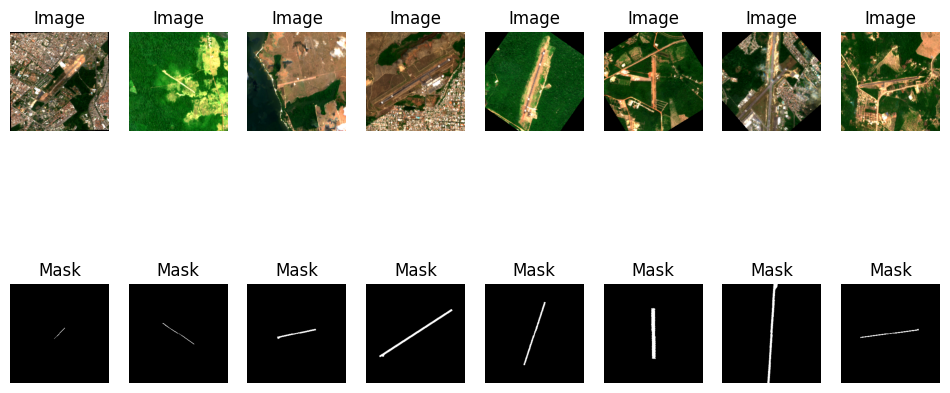

In [ ]:
#===================================
# Mostrar 1 batch
#==================================

images, masks = next(iter(train_loader))

plt.figure(figsize=(12,6))
for i in range(len(images)):
    plt.subplot(2, len(images), i+1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title("Image")
    plt.axis("off")

    plt.subplot(2, len(images), i+1+len(images))
    plt.imshow(masks[i].squeeze(), cmap="gray")
    plt.title("Mask")
    plt.axis("off")

In [ ]:
#===================================
# 4: Construir modelo
#==================================

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )
        
        self.enc1 = conv_block(5, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.enc4 = conv_block(256, 512)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(512, 1024)

        self.upconv4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = conv_block(1024, 512)

        self.upconv3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(512, 256)

        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)

        self.upconv1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.conv_last = nn.Conv2d(64, 1, kernel_size=1)
    
    def forward(self, x):
        c1 = self.enc1(x)
        p1 = self.pool(c1)

        c2 = self.enc2(p1)
        p2 = self.pool(c2)

        c3 = self.enc3(p2)
        p3 = self.pool(c3)

        c4 = self.enc4(p3)
        p4 = self.pool(c4)

        bottleneck = self.bottleneck(p4)

        u4 = self.upconv4(bottleneck)
        u4 = torch.cat([u4, c4], dim=1)
        d4 = self.dec4(u4)

        u3 = self.upconv3(d4)
        u3 = torch.cat([u3, c3], dim=1)
        d3 = self.dec3(u3)

        u2 = self.upconv2(d3)
        u2 = torch.cat([u2, c2], dim=1)
        d2 = self.dec2(u2)

        u1 = self.upconv1(d2)
        u1 = torch.cat([u1, c1], dim=1)
        d1 = self.dec1(u1)

        return torch.sigmoid(self.conv_last(d1))




In [ ]:
#===================================
# 5: Setup de treino
#==================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = pred.view(-1)
        target = target.view(-1)
        
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        
        return 1 - dice

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = UNet().to(device)
#criterion = nn.BCELoss()
criterion = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

cuda


In [136]:
#===================================
# 6: Loop de treino
#==================================

num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    val_loss = 0
    model.eval()
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, masks)
            val_loss += loss.item()
    
    print(f"Época: {epoch} concluída")
    
print(f"Epoca {epoch+1}/{num_epochs}, perda treino: {train_loss/len(train_loader)}, Val Loss: {val_loss/len(val_loader):.4f}")

Época: 0 concluída
Época: 1 concluída
Época: 2 concluída
Época: 3 concluída
Época: 4 concluída
Época: 5 concluída
Época: 6 concluída
Época: 7 concluída
Época: 8 concluída
Época: 9 concluída
Época: 10 concluída
Época: 11 concluída
Época: 12 concluída
Época: 13 concluída
Época: 14 concluída
Época: 15 concluída
Época: 16 concluída
Época: 17 concluída
Época: 18 concluída
Época: 19 concluída
Época: 20 concluída
Época: 21 concluída
Época: 22 concluída
Época: 23 concluída
Época: 24 concluída
Época: 25 concluída
Época: 26 concluída
Época: 27 concluída
Época: 28 concluída
Época: 29 concluída
Época: 30 concluída
Época: 31 concluída
Época: 32 concluída
Época: 33 concluída
Época: 34 concluída
Época: 35 concluída
Época: 36 concluída
Época: 37 concluída
Época: 38 concluída
Época: 39 concluída
Época: 40 concluída
Época: 41 concluída
Época: 42 concluída
Época: 43 concluída
Época: 44 concluída
Época: 45 concluída
Época: 46 concluída
Época: 47 concluída
Época: 48 concluída
Época: 49 concluída
Epoca 50/5

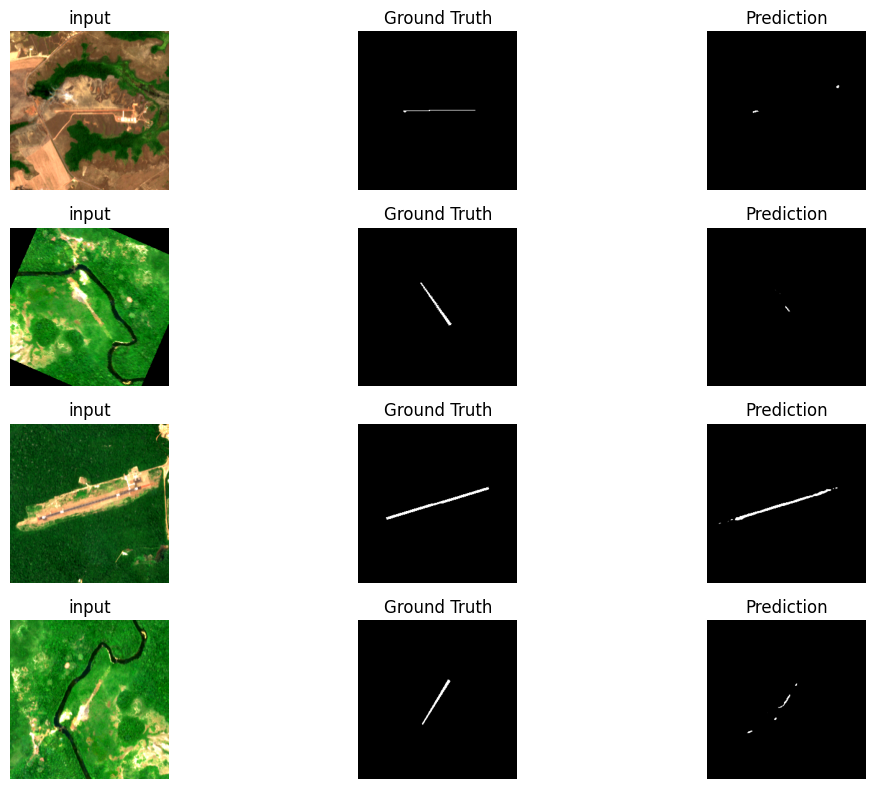

In [149]:
#===================================

# 7: vizualizar predições aleatórias

#==================================
model.eval()

indices = random.sample(range(len(val_dataset)), 4)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(indices):

    img, mask = val_dataset[idx]
    img, masks = img.unsqueeze(0).to(device), mask.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(img)

    img_np = img.squeeze().permute(1, 2, 0).cpu().numpy()
    mask_np = mask.squeeze().cpu().numpy()
    pred_np = pred.squeeze().cpu().numpy()

    plt.subplot(4, 3, i*3 + 1)
    plt.imshow(img_np)
    plt.title("input")
    plt.axis("off")

    plt.subplot(4, 3, i*3 + 2)
    plt.imshow(mask_np, cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(4, 3, i*3 + 3)
    plt.imshow(pred_np, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
ee.Initialize(project="desafio-solved")

municipios = ee.FeatureCollection("FAO/GAUL/2015/level2")

lista_municipios = [
    'Altamira', 'Anapu', 'Brasil Novo', 'Medicilandia',
    'Pacaja', 'Senador Jose Porfirio', 'Uruara', 'Vitoria do Xingu',
    'Itaituba', 'Aveiro', 'Jacareacanga', 'Novo Progresso',
    'Ruropolis', 'Trairao'
]

sudoeste = municipios.filter(ee.Filter.inList("ADM2_NAME", lista_municipios))

roi = sudoeste.geometry()

colecao = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(roi)
    .filterDate('2023-01-01', '2023-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

imagem = colecao.median().clip(roi)

mapa = geemap.Map()
mapa.centerObject(roi, 7)

mapa.addLayer(imagem, {
    'bands': ['B4', 'B3', 'B2'],
    'min': 0,
    'max': 3000
}, 'Sudoeste do Pará')

mapa


NameError: name 'ee' is not defined